In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score,roc_curve,
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline          
df=pd.read_csv('output.csv')
x=df.iloc[:,4:-2]
y=df.iloc[:,-2]
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=12)


In [47]:
pipe=make_pipeline(StandardScaler(),LogisticRegression(random_state=12,verbose=0))
pipe.fit(x_train,y_train)
print(pipe.score(x_test,y_test))

0.8928571428571429


In [22]:
pipe.classes_

array(['female', 'male'], dtype=object)

In [ ]:
y_prob=pipe.predict_proba(x_test)[:,1] #if it is 0 shows first class if 1 shows second class ['male']
fpr,tpr,trash= roc_curve(y_test,y_prob,pos_label='male')
score = roc_auc_score(y_test,y_prob,labels=['female','male'])
print(score)

0.9603220241518113


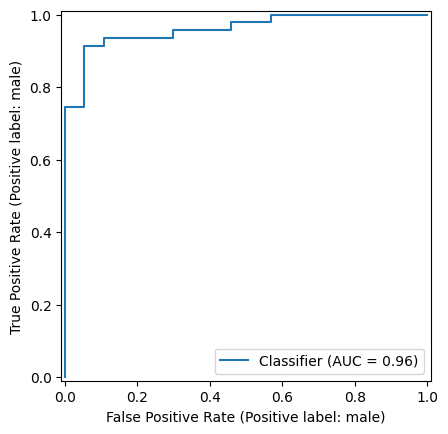

In [53]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_prob,pos_label='male')

In [33]:
pipe[1].coef_

array([[ 0.39496921,  2.85604452, -0.18650584,  3.07669787]])